# NOAA Storm Events (2015–2024): Property Damage Analysis & Prediction

## 1. Project Overview

This project analyzes 10 years (2015–2024) of severe weather events from the NOAA/NCEI Storm Events Database (~639,000 records) to understand patterns in storm frequency, property damage, injuries, and deaths across event types, states, and time — and to build a model predicting property damage for a given storm event.

**Structure:**
1. Project Overview
2. Data Collection & Cleaning
3. Exploratory Data Analysis
4. Geospatial Analysis
5. Temporal & Seasonal Analysis
6. Property Damage Prediction
7. Model Evaluation
8. Key Findings
9. Limitations & Future Work

## 2. Data Collection & Cleaning

In [8]:
import pandas as pd
years = {
    2015: "StormEvents_details-ftp_v1.0_d2015_c20260323.csv.gz",
    2016: "StormEvents_details-ftp_v1.0_d2016_c20260323.csv.gz",
    2017: "StormEvents_details-ftp_v1.0_d2017_c20260519.csv.gz",
    2018: "StormEvents_details-ftp_v1.0_d2018_c20260323.csv.gz",
    2019: "StormEvents_details-ftp_v1.0_d2019_c20260323.csv.gz",
    2020: "StormEvents_details-ftp_v1.0_d2020_c20260323.csv.gz",
    2021: "StormEvents_details-ftp_v1.0_d2021_c20260323.csv.gz",
    2022: "StormEvents_details-ftp_v1.0_d2022_c20260625.csv.gz",
    2023: "StormEvents_details-ftp_v1.0_d2023_c20260323.csv.gz",
    2024: "StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz",
}

base_url = "https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/"

all_years = []
for year, filename in years.items():
    print(f"Downloading {year}...")
    df_year = pd.read_csv(base_url + filename, compression="gzip", low_memory=False)
    all_years.append(df_year)
    print(f"  -> {len(df_year):,} rows")

storm_data = pd.concat(all_years, ignore_index=True)
print(f"\nTotal rows across all years: {len(storm_data):,}")
storm_data.head()

  -> 57,907 rows
  -> 56,005 rows
  -> 57,041 rows
  -> 62,699 rows
  -> 67,864 rows
  -> 61,281 rows
  -> 61,389 rows
  -> 69,887 rows
  -> 75,593 rows
  -> 69,801 rows

Total rows across all years: 639,467


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,201509,18,1544,201509,18,1553,99979,602745,ILLINOIS,17,...,4.0,W,MONEE,41.4164,-87.86,41.4266,-87.8119,A low pressure system moved towards northern I...,A spotter was located near Green Garden Rd and...,CSV
1,201501,27,1200,201501,28,400,92561,559139,NEW HAMPSHIRE,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure developed off the Delm...,"Once blizzard conditions subsided, snow and bl...",CSV
2,201501,24,700,201501,24,2100,92625,555067,NEW HAMPSHIRE,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure moving rapidly northea...,NaN,CSV
3,201501,27,600,201501,27,1200,92561,554564,NEW HAMPSHIRE,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure developed off the Delm...,NaN,CSV
4,201502,14,800,201502,15,1700,93895,564438,NEW HAMPSHIRE,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low pressure dropping southeast from Canada on...,NaN,CSV


In [9]:
storm_data.shape
storm_data.columns
storm_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639467 entries, 0 to 639466
Data columns (total 51 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   BEGIN_YEARMONTH     639467 non-null  int64  
 1   BEGIN_DAY           639467 non-null  int64  
 2   BEGIN_TIME          639467 non-null  int64  
 3   END_YEARMONTH       639467 non-null  int64  
 4   END_DAY             639467 non-null  int64  
 5   END_TIME            639467 non-null  int64  
 6   EPISODE_ID          639467 non-null  int64  
 7   EVENT_ID            639467 non-null  int64  
 8   STATE               639467 non-null  object 
 9   STATE_FIPS          639467 non-null  int64  
 10  YEAR                639467 non-null  int64  
 11  MONTH_NAME          639467 non-null  object 
 12  EVENT_TYPE          639467 non-null  object 
 13  CZ_TYPE             639467 non-null  object 
 14  CZ_FIPS             639467 non-null  int64  
 15  CZ_NAME             639467 non-nul

In [10]:
print(storm_data.DAMAGE_PROPERTY.notna().sum())
print(storm_data.DAMAGE_PROPERTY.isna().sum())

506905
132562


In [11]:
import numpy as np
k=1000
m=1000000
b=1000000000

def parse_damage_value(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().upper()
    if value.endswith('K'):
        return float(value[:-1]) * k
    elif value.endswith('M'):
        return float(value[:-1]) * m
    elif value.endswith('B'):
        return float(value[:-1]) * b
    else:
        try:
            return float(value)
        except ValueError:
            return np.nan

storm_data['DAMAGE_PROPERTY_NUM'] = storm_data['DAMAGE_PROPERTY'].apply(parse_damage_value)

print("Original 'DAMAGE_PROPERTY' column head and new 'DAMAGE_PROPERTY_NUM' column:")
display(storm_data[['DAMAGE_PROPERTY', 'DAMAGE_PROPERTY_NUM']].head())

print("\nInfo for the new 'DAMAGE_PROPERTY_NUM' column:")
storm_data['DAMAGE_PROPERTY_NUM'].info()

Original 'DAMAGE_PROPERTY' column head and new 'DAMAGE_PROPERTY_NUM' column:


,DAMAGE_PROPERTY,DAMAGE_PROPERTY_NUM
0,70000,70000.0
1,0.00K,0.0
2,0.00K,0.0
3,0.00K,0.0
4,0.00K,0.0



Info for the new 'DAMAGE_PROPERTY_NUM' column:
<class 'pandas.core.series.Series'>
RangeIndex: 639467 entries, 0 to 639466
Series name: DAMAGE_PROPERTY_NUM
Non-Null Count   Dtype  
--------------   -----  
506905 non-null  float64
dtypes: float64(1)
memory usage: 4.9 MB


In [12]:
print(f"Number of missing values in 'DAMAGE_PROPERTY_NUM': {storm_data['DAMAGE_PROPERTY_NUM'].isnull().sum()}")

Number of missing values in 'DAMAGE_PROPERTY_NUM': 132562


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Exploratory Data Analysis

### Event Type Distribution

Top 15 Most Frequent Event Types:


,count
EVENT_TYPE,
Thunderstorm Wind,173391
Hail,87889
Flash Flood,40522
High Wind,36557
Winter Weather,36376
Drought,30800
Flood,28549
Winter Storm,28190
Marine Thunderstorm Wind,23718


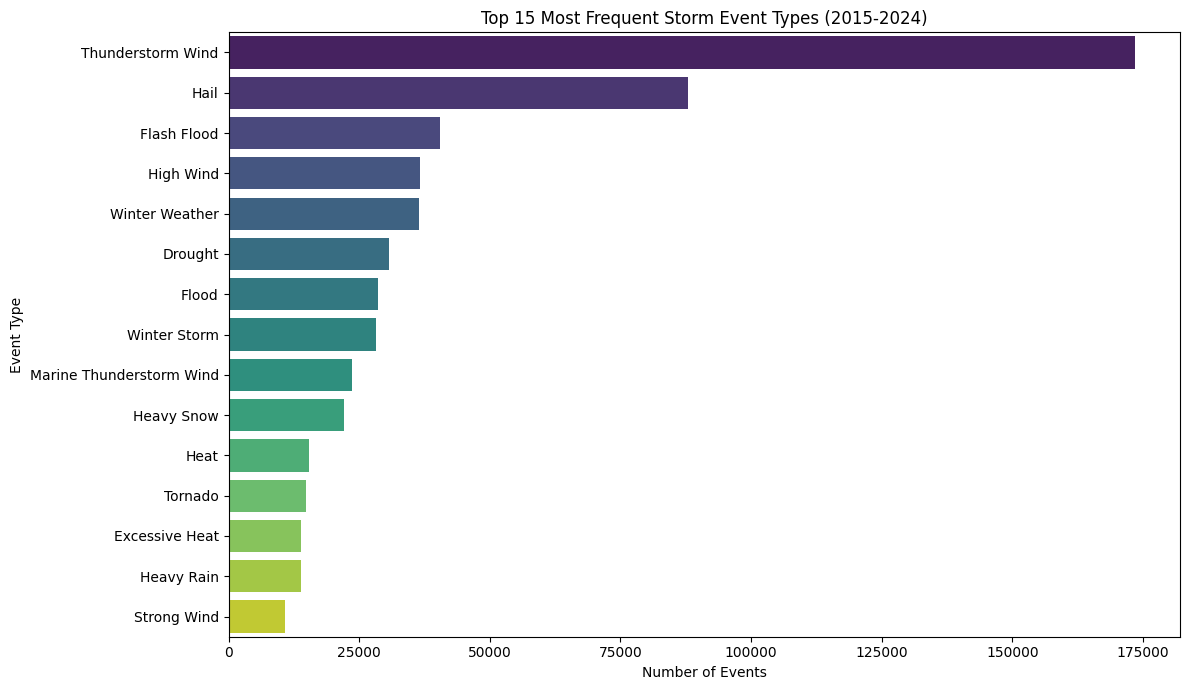

In [14]:
# Get the top 15 most frequent event types
top_event_types = storm_data['EVENT_TYPE'].value_counts().head(15)

print("Top 15 Most Frequent Event Types:")
display(top_event_types)

# Visualize the distribution of event types
plt.figure(figsize=(12, 7))
sns.barplot(y=top_event_types.index, x=top_event_types.values, palette='viridis', hue=top_event_types.index, legend=False)
plt.title('Top 15 Most Frequent Storm Event Types (2015-2024)')
plt.xlabel('Number of Events')
plt.ylabel('Event Type')
plt.tight_layout()
plt.show()

### State Distribution

Top 15 States by Number of Storm Events:


,count
STATE,
TEXAS,47668
KANSAS,23018
CALIFORNIA,22005
OKLAHOMA,21004
VIRGINIA,20952
SOUTH DAKOTA,20359
IOWA,20241
MISSOURI,20195
NEW YORK,19560


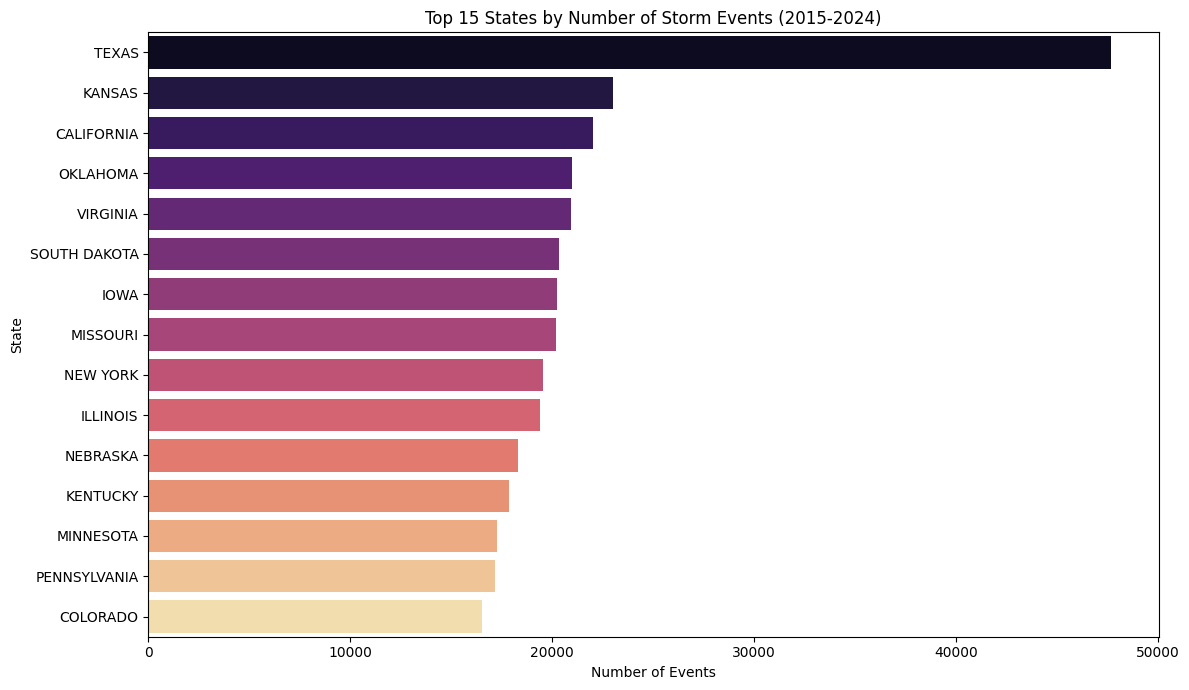

In [15]:
# Get the top 15 states with the most events
top_states = storm_data['STATE'].value_counts().head(15)

print("Top 15 States by Number of Storm Events:")
display(top_states)

# Visualize the distribution of states
plt.figure(figsize=(12, 7))
sns.barplot(y=top_states.index, x=top_states.values, palette='magma', hue=top_states.index, legend=False)
plt.title('Top 15 States by Number of Storm Events (2015-2024)')
plt.xlabel('Number of Events')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Property Damage by Event Type

Top 15 Event Types by Total Property Damage:


,DAMAGE_PROPERTY_NUM
EVENT_TYPE,
Flash Flood,7.951951e+10
Hurricane (Typhoon),6.944611e+10
Wildfire,2.943086e+10
Flood,1.412760e+10
Hail,1.143815e+10
Tornado,1.142055e+10
Tropical Storm,1.107175e+10
Storm Surge/Tide,7.034722e+09
High Wind,5.634877e+09


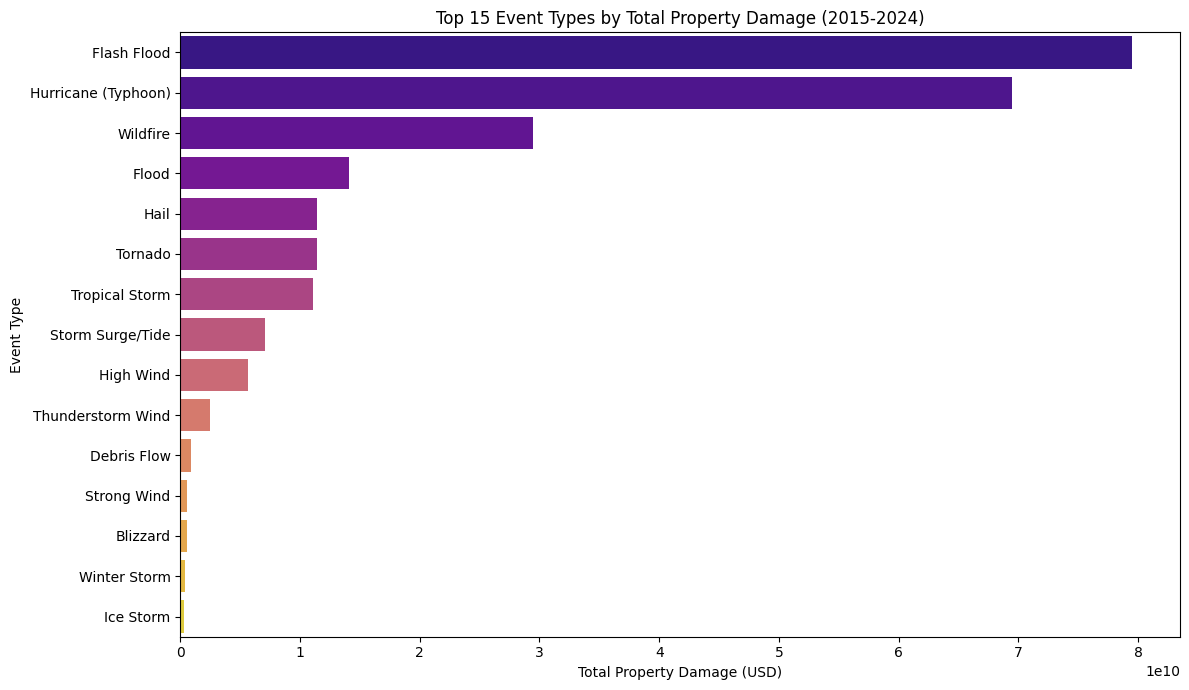

In [16]:
# Group by EVENT_TYPE and sum DAMAGE_PROPERTY_NUM
damage_by_event_type = storm_data.groupby('EVENT_TYPE')['DAMAGE_PROPERTY_NUM'].sum()

# Get the top 15 event types by total damage
top_damage_event_types = damage_by_event_type.nlargest(15)

print("Top 15 Event Types by Total Property Damage:")
display(top_damage_event_types)

# Visualize the distribution of damage by event types
plt.figure(figsize=(12, 7))
sns.barplot(y=top_damage_event_types.index, x=top_damage_event_types.values, palette='plasma', hue=top_damage_event_types.index, legend=False)
plt.title('Top 15 Event Types by Total Property Damage (2015-2024)')
plt.xlabel('Total Property Damage (USD)')
plt.ylabel('Event Type')
plt.tight_layout()
plt.show()

### Injuries by Event Type

Top 15 Event Types by Total Direct Injuries:


,INJURIES_DIRECT
EVENT_TYPE,
Tornado,6036
Excessive Heat,2594
Heat,1744
Thunderstorm Wind,1488
Lightning,790
Wildfire,624
Hurricane (Typhoon),440
Drought,350
Rip Current,335


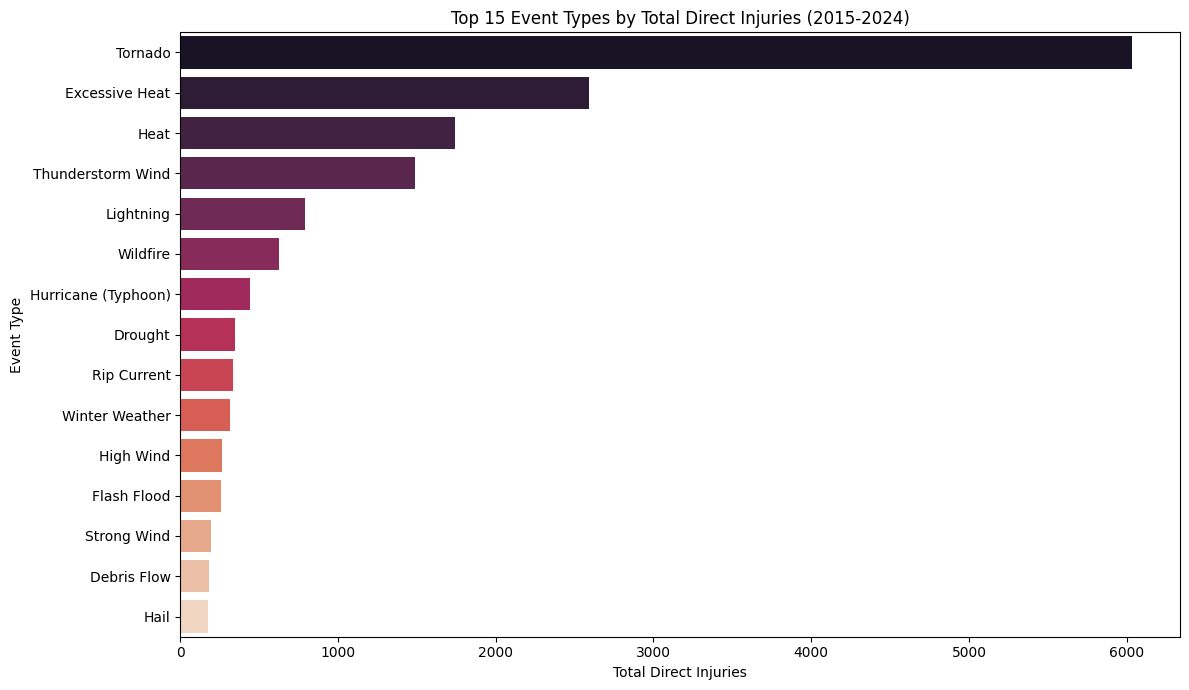

In [17]:
# Group by EVENT_TYPE and sum INJURIES_DIRECT
injuries_by_event_type = storm_data.groupby('EVENT_TYPE')['INJURIES_DIRECT'].sum()

# Get the top 15 event types by total injuries
top_injuries_event_types = injuries_by_event_type.nlargest(15)

print("Top 15 Event Types by Total Direct Injuries:")
display(top_injuries_event_types)

# Visualize the distribution of injuries by event types
plt.figure(figsize=(12, 7))
sns.barplot(y=top_injuries_event_types.index, x=top_injuries_event_types.values, palette='rocket', hue=top_injuries_event_types.index, legend=False)
plt.title('Top 15 Event Types by Total Direct Injuries (2015-2024)')
plt.xlabel('Total Direct Injuries')
plt.ylabel('Event Type')
plt.tight_layout()
plt.show()

### Deaths by Event Type

Top 15 Event Types by Total Direct Deaths:


,DEATHS_DIRECT
EVENT_TYPE,
Excessive Heat,1563
Heat,1078
Flash Flood,843
Rip Current,658
Tornado,480
Wildfire,329
Thunderstorm Wind,322
Flood,290
Cold/Wind Chill,283


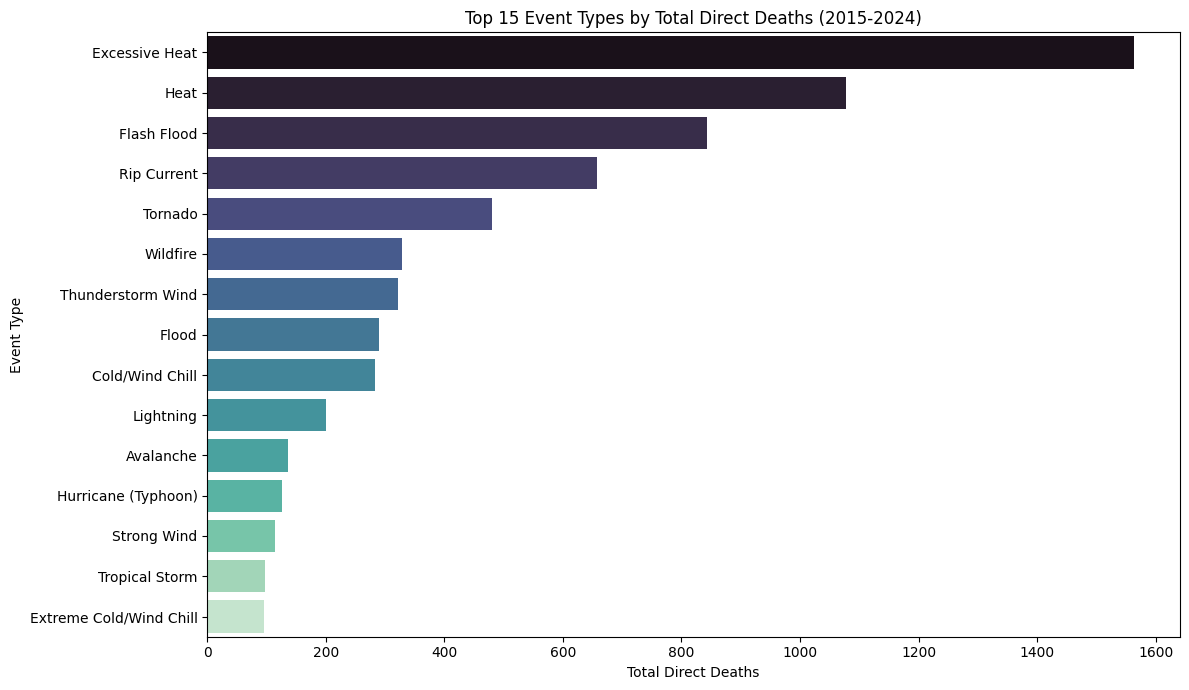

In [18]:
# Group by EVENT_TYPE and sum DEATHS_DIRECT
deaths_by_event_type = storm_data.groupby('EVENT_TYPE')['DEATHS_DIRECT'].sum()

# Get the top 15 event types by total deaths
top_deaths_event_types = deaths_by_event_type.nlargest(15)

print("Top 15 Event Types by Total Direct Deaths:")
display(top_deaths_event_types)

# Visualize the distribution of deaths by event types
plt.figure(figsize=(12, 7))
sns.barplot(y=top_deaths_event_types.index, x=top_deaths_event_types.values, palette='mako', hue=top_deaths_event_types.index, legend=False)
plt.title('Top 15 Event Types by Total Direct Deaths (2015-2024)')
plt.xlabel('Total Direct Deaths')
plt.ylabel('Event Type')
plt.tight_layout()
plt.show()

### Property Damage by State

Top 15 States by Property Damage:


,DAMAGE_PROPERTY_NUM
STATE,
TEXAS,6.898090e+10
FLORIDA,4.172427e+10
LOUISIANA,3.737839e+10
CALIFORNIA,2.204276e+10
PUERTO RICO,1.904908e+10
GUAM,6.057178e+09
NORTH CAROLINA,5.867128e+09
HAWAII,5.689649e+09
COLORADO,5.517075e+09


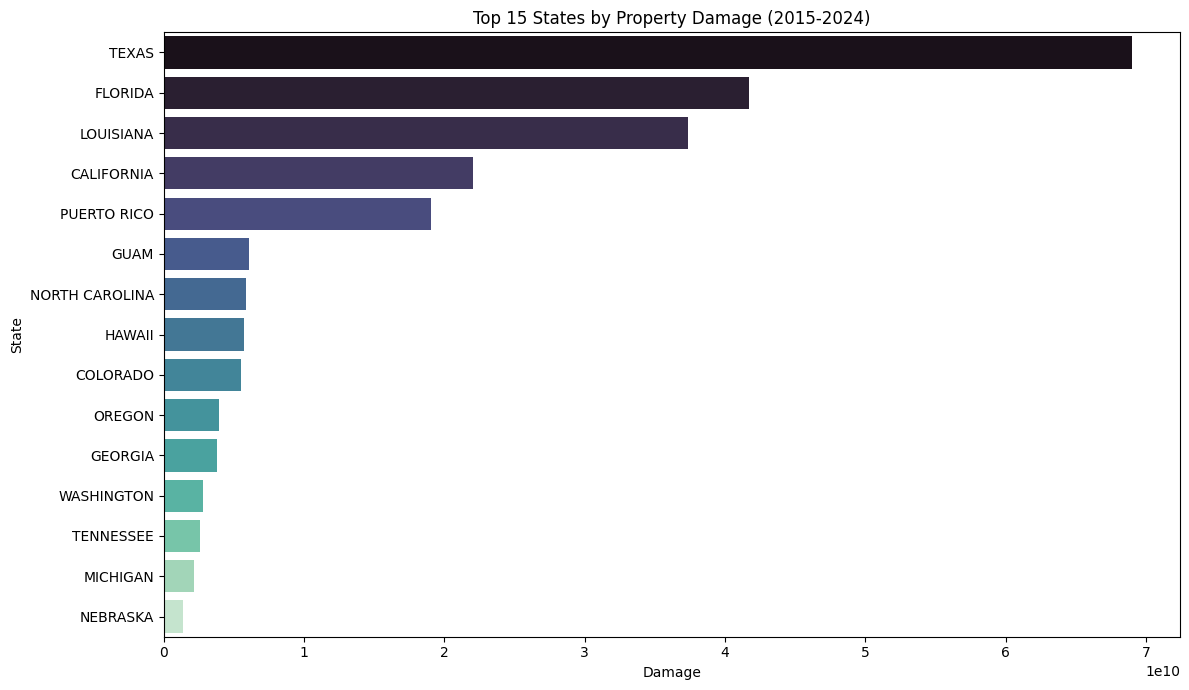

In [19]:
# Group by STATE and sum DAMAGE_PROPERTY_NUM
states_by_loss = storm_data.groupby('STATE')['DAMAGE_PROPERTY_NUM'].sum()

# Get the top 15 event states by total loss
top_states_loss = states_by_loss.nlargest(15)

print("Top 15 States by Property Damage:")
display(top_states_loss)


# Visualize the distribution of loss by state
plt.figure(figsize=(12, 7))
sns.barplot(y=top_states_loss.index, x=top_states_loss.values, palette='mako', hue=top_states_loss.index, legend=False)
plt.title('Top 15 States by Property Damage (2015-2024)')
plt.xlabel('Damage')
plt.ylabel('State')
plt.tight_layout()
plt.show()


### Injuries by State

Top 15 States by Injuries:


,INJURIES_DIRECT
STATE,
TEXAS,3276
MISSOURI,1259
OKLAHOMA,1223
CALIFORNIA,1068
KENTUCKY,822
TENNESSEE,673
MISSISSIPPI,648
GEORGIA,584
ARKANSAS,562


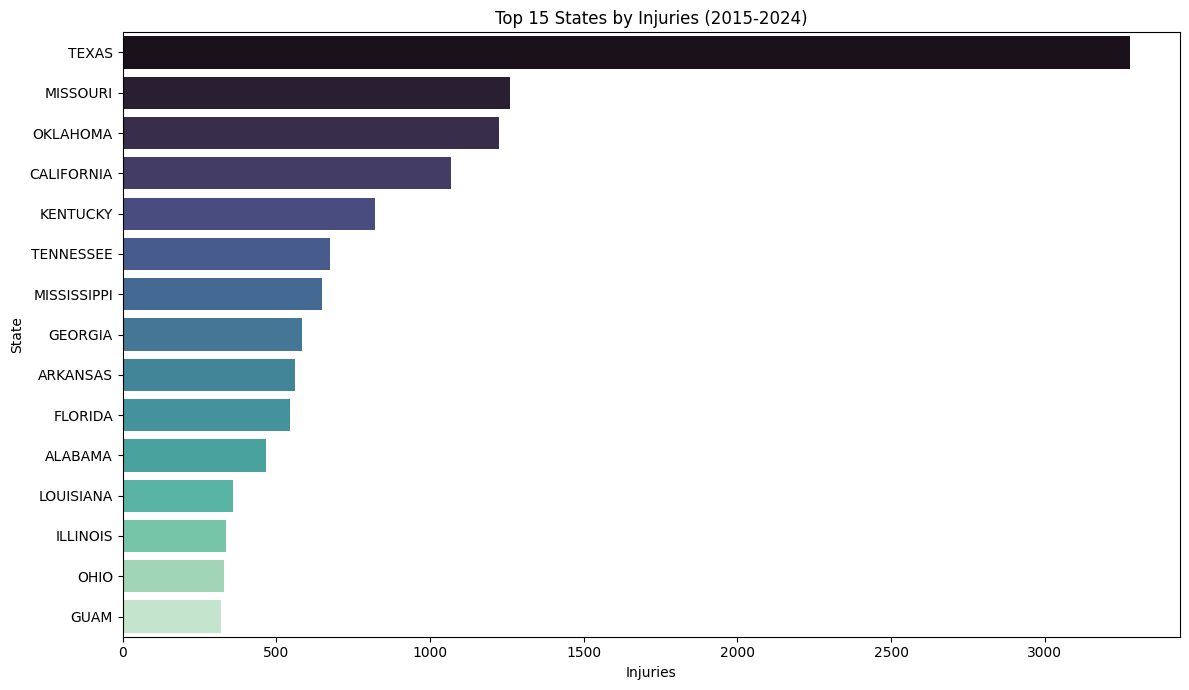

In [20]:
# Group by STATE and sum INJURIES_DIRECT
states_by_injuries = storm_data.groupby('STATE')['INJURIES_DIRECT'].sum()

# Get the top 15 event states by injuries
top_states_injuries = states_by_injuries.nlargest(15)

print("Top 15 States by Injuries:")
display(top_states_injuries)


# Visualize the distribution of injuries by state
plt.figure(figsize=(12, 7))
sns.barplot(y=top_states_injuries.index, x=top_states_injuries.values, palette='mako', hue=top_states_injuries.index, legend=False)
plt.title('Top 15 States by Injuries (2015-2024)')
plt.xlabel('Injuries')
plt.ylabel('State')
plt.tight_layout()
plt.show()



## 4. Geospatial Analysis

### Storm Event Hotspots

The interactive maps below are saved as standalone HTML files (`storm_event_hotspots.html`, `property_damage_hotspots.html`) when the notebook is run, open them in a browser.

In [21]:
import folium
from folium.plugins import HeatMap

# Filter out rows with missing latitude or longitude
geo_data = storm_data.dropna(subset=['BEGIN_LAT', 'BEGIN_LON'])

# Take a sample of the data for initial visualization due to the large number of events
# You can adjust the sample size as needed, or remove it for all data points if performance allows
sample_geo_data = geo_data.sample(n=50000, random_state=42)

# Create a base map centered around the mean latitude and longitude of the sampled data
map_center_lat = sample_geo_data['BEGIN_LAT'].mean()
map_center_lon = sample_geo_data['BEGIN_LON'].mean()
m = folium.Map(location=[map_center_lat, map_center_lon], zoom_start=4)

# Prepare data for HeatMap plugin (list of [latitude, longitude])
heat_data = [[row['BEGIN_LAT'], row['BEGIN_LON']] for index, row in sample_geo_data.iterrows()]


# Add HeatMap to the map with adjusted parameters for clearer hotspots
# Decreasing radius and blur, and adding min_opacity for better contrast
HeatMap(heat_data, radius=12, blur=8, min_opacity=0.4).add_to(m)

# Display the map
m

m.save('storm_event_hotspots.html')  # standalone interactive map (GitHub doesn't render folium in notebooks)


### Property Damage Hotspots

In [22]:
import folium
from folium.plugins import HeatMap

# Filter out rows with missing latitude, longitude, or damage values
geo_damage_data = storm_data.dropna(subset=['BEGIN_LAT', 'BEGIN_LON', 'DAMAGE_PROPERTY_NUM'])

# Take a sample for initial visualization. Adjust if needed.
sample_geo_damage_data = geo_damage_data.sample(n=50000, random_state=42)

# Create a base map centered around the mean latitude and longitude of the sampled data
map_center_lat_damage = sample_geo_damage_data['BEGIN_LAT'].mean()
map_center_lon_damage = sample_geo_damage_data['BEGIN_LON'].mean()
m_damage = folium.Map(location=[map_center_lat_damage, map_center_lon_damage], zoom_start=4)

# Prepare data for HeatMap plugin (list of [latitude, longitude, weight])
# The weight here is DAMAGE_PROPERTY_NUM
heat_data_damage = [
    [row['BEGIN_LAT'], row['BEGIN_LON'], row['DAMAGE_PROPERTY_NUM']]
    for index, row in sample_geo_damage_data.iterrows()
]

# Add HeatMap to the map with adjusted parameters for clearer hotspots
# Decreasing radius and blur, and adding min_opacity for better contrast
HeatMap(heat_data_damage, radius=12, blur=8, min_opacity=0.4).add_to(m_damage)

# Display the map
m_damage

m_damage.save('property_damage_hotspots.html')  # standalone interactive map


## 5. Temporal & Seasonal Analysis

### Preparing Temporal Fields

In [23]:
storm_data['BEGIN_DATE_TIME'] = pd.to_datetime(storm_data['BEGIN_DATE_TIME'], format='%d-%b-%y %H:%M:%S', errors='coerce')

# Extract Year and Month
storm_data['YEAR'] = storm_data['BEGIN_DATE_TIME'].dt.year
storm_data['MONTH'] = storm_data['BEGIN_DATE_TIME'].dt.month
storm_data['MONTH_NAME'] = storm_data['BEGIN_DATE_TIME'].dt.month_name()

# Display the updated DataFrame info and head to verify new columns
print('Updated DataFrame info with YEAR, MONTH, MONTH_NAME:')
storm_data[['BEGIN_DATE_TIME', 'YEAR', 'MONTH', 'MONTH_NAME']].info()
display(storm_data[['BEGIN_DATE_TIME', 'YEAR', 'MONTH', 'MONTH_NAME']].head())

Updated DataFrame info with YEAR, MONTH, MONTH_NAME:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639467 entries, 0 to 639466
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   BEGIN_DATE_TIME  639467 non-null  datetime64[ns]
 1   YEAR             639467 non-null  int32         
 2   MONTH            639467 non-null  int32         
 3   MONTH_NAME       639467 non-null  object        
dtypes: datetime64[ns](1), int32(2), object(1)
memory usage: 14.6+ MB


,BEGIN_DATE_TIME,YEAR,MONTH,MONTH_NAME
0,2015-09-18 15:44:00,2015,9,September
1,2015-01-27 12:00:00,2015,1,January
2,2015-01-24 07:00:00,2015,1,January
3,2015-01-27 06:00:00,2015,1,January
4,2015-02-14 08:00:00,2015,2,February


### Yearly Trends

#### Number of Storm Events

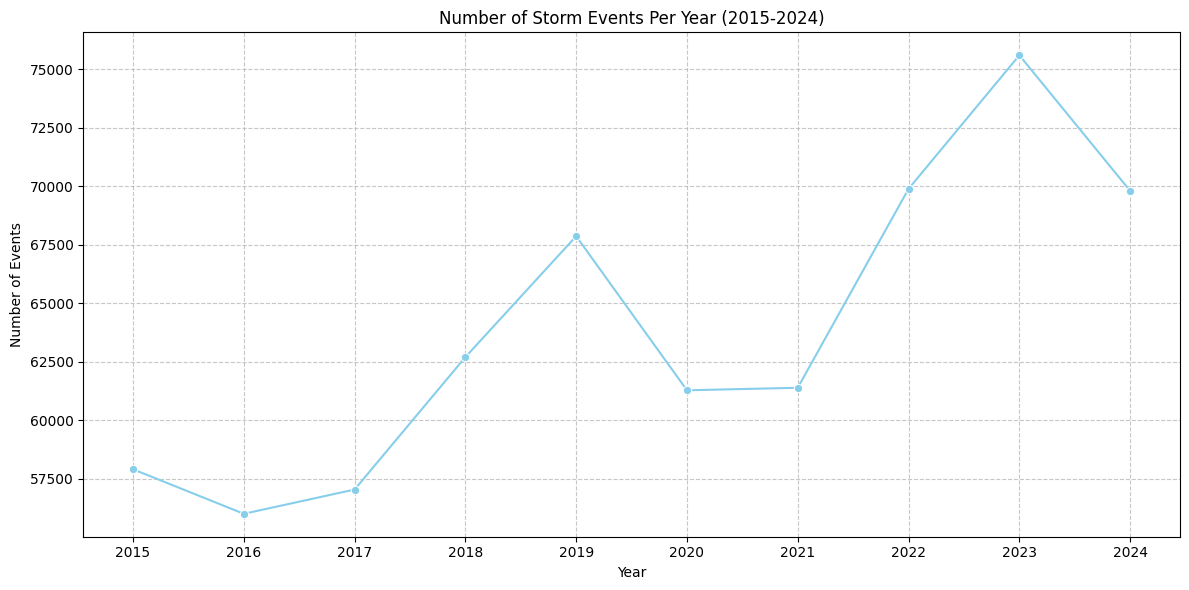

In [24]:
# Calculate number of events per year
events_per_year = storm_data['YEAR'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(x=events_per_year.index, y=events_per_year.values, marker='o', color='skyblue')
plt.title('Number of Storm Events Per Year (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.xticks(events_per_year.index) # Ensure all years are shown as x-ticks
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Total Property Damage

The check below shows how much damage data is actually populated each year. 2024 has almost no events with nonzero reported damage in this NOAA release, so 2024 is excluded from the **yearly** damage plot to avoid a misleading drop-off.

In [25]:
# Data quality check: how populated is the damage field each year?
dq = storm_data.groupby('YEAR')['DAMAGE_PROPERTY_NUM'].agg(
    events='size',
    share_reported=lambda s: s.notna().mean(),
    nonzero_events=lambda s: (s > 0).sum(),
)
display(dq)

,events,share_reported,nonzero_events
YEAR,,,
2015,57907,0.826066,12770
2016,56005,0.791215,11784
2017,57041,0.814344,13439
2018,62699,0.804766,11841
2019,67864,0.804152,14017
2020,61281,0.790131,12355
2021,61389,0.795615,11584
2022,69887,0.765464,11341
2023,75593,0.764132,13664


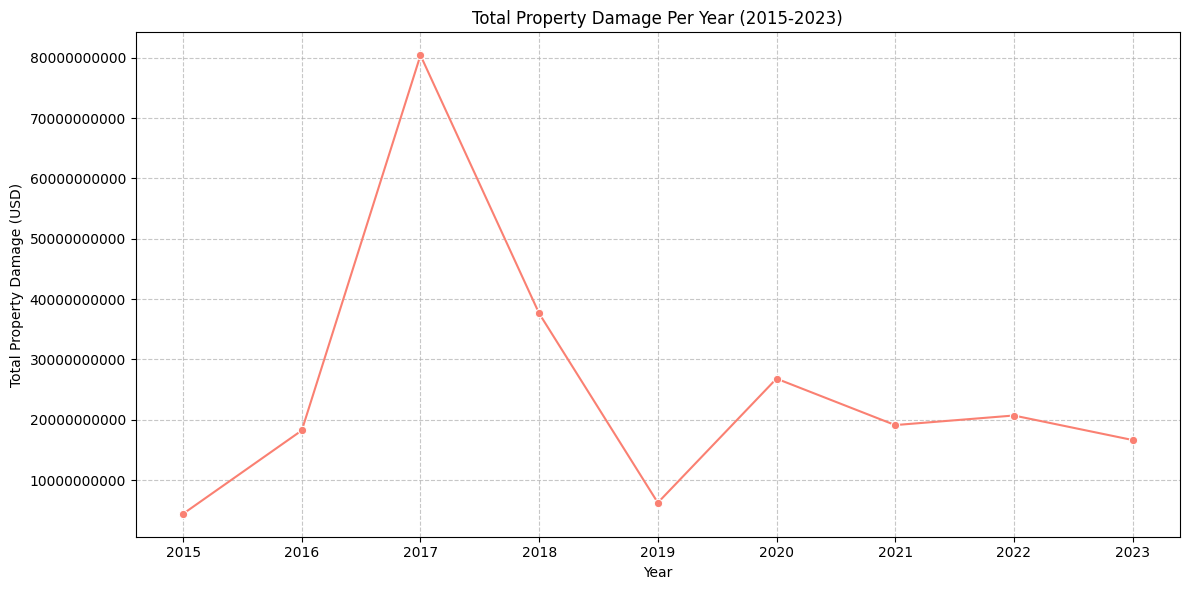

In [26]:
# Calculate total property damage per year
damage_per_year = storm_data.groupby('YEAR')['DAMAGE_PROPERTY_NUM'].sum()
damage_per_year = damage_per_year.loc[:2023]  # 2024 damage values are largely unpopulated (see check above)

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(x=damage_per_year.index, y=damage_per_year.values, marker='o', color='salmon')
plt.title('Total Property Damage Per Year (2015-2023)')
plt.xlabel('Year')
plt.ylabel('Total Property Damage (USD)')
plt.xticks(damage_per_year.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.tight_layout()
plt.show()

#### Total Direct Injuries

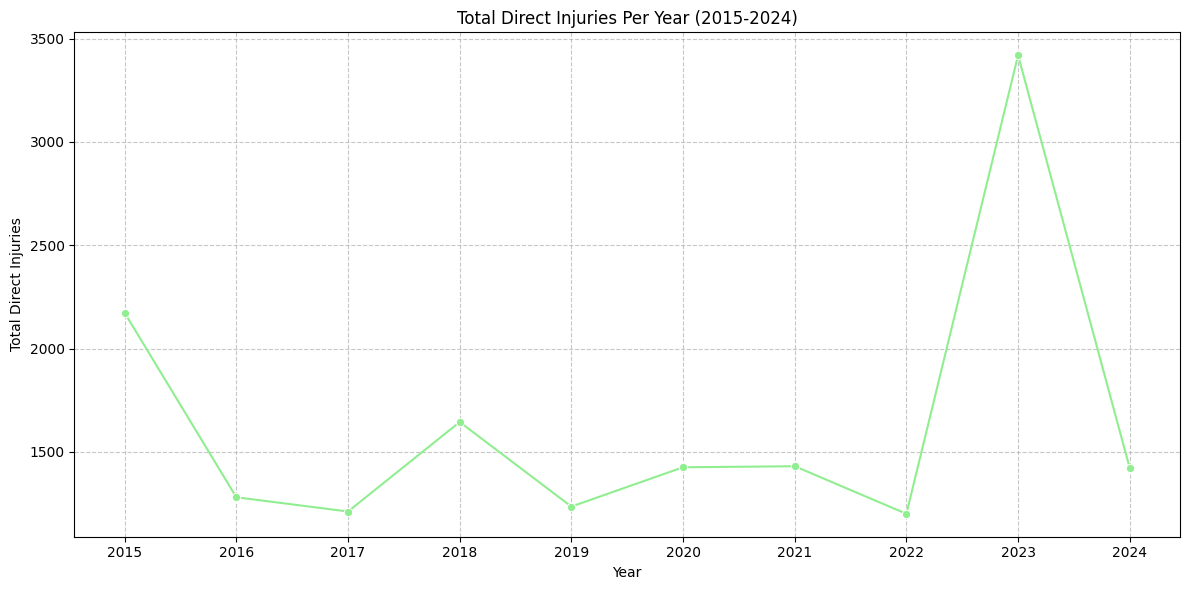

In [27]:
# Calculate total direct injuries per year
injuries_per_year = storm_data.groupby('YEAR')['INJURIES_DIRECT'].sum()

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(x=injuries_per_year.index, y=injuries_per_year.values, marker='o', color='lightgreen')
plt.title('Total Direct Injuries Per Year (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Total Direct Injuries')
plt.xticks(injuries_per_year.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Total Direct Deaths

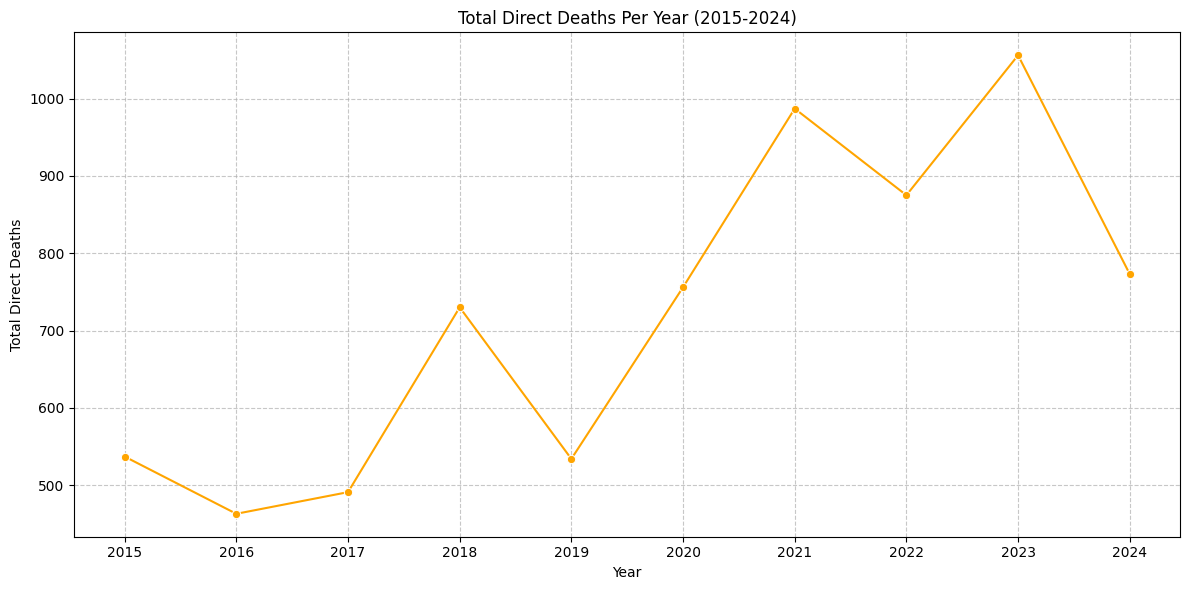

In [28]:
# Calculate total direct deaths per year
deaths_per_year = storm_data.groupby('YEAR')['DEATHS_DIRECT'].sum()

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(x=deaths_per_year.index, y=deaths_per_year.values, marker='o', color='orange')
plt.title('Total Direct Deaths Per Year (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Total Direct Deaths')
plt.xticks(deaths_per_year.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Monthly Trends

#### Number of Storm Events

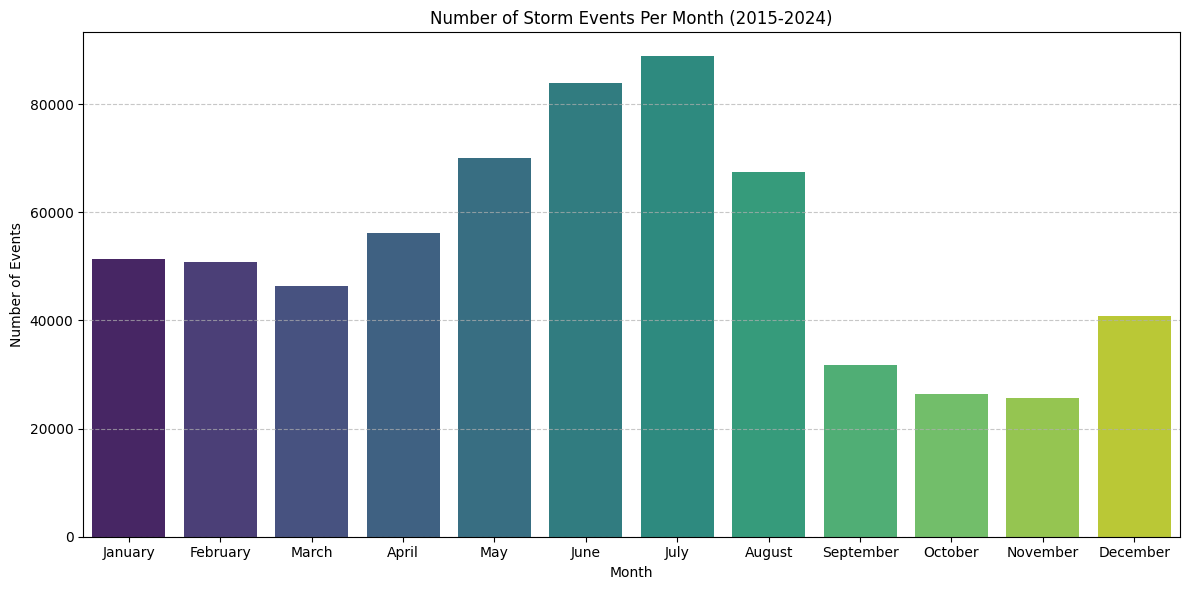

In [29]:
# Calculate number of events per month
events_per_month = storm_data['MONTH_NAME'].value_counts().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December']
)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=events_per_month.index, y=events_per_month.values, palette='viridis', hue=events_per_month.index, legend=False)
plt.title('Number of Storm Events Per Month (2015-2024)')
plt.xlabel('Month')
plt.ylabel('Number of Events')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Total Property Damage

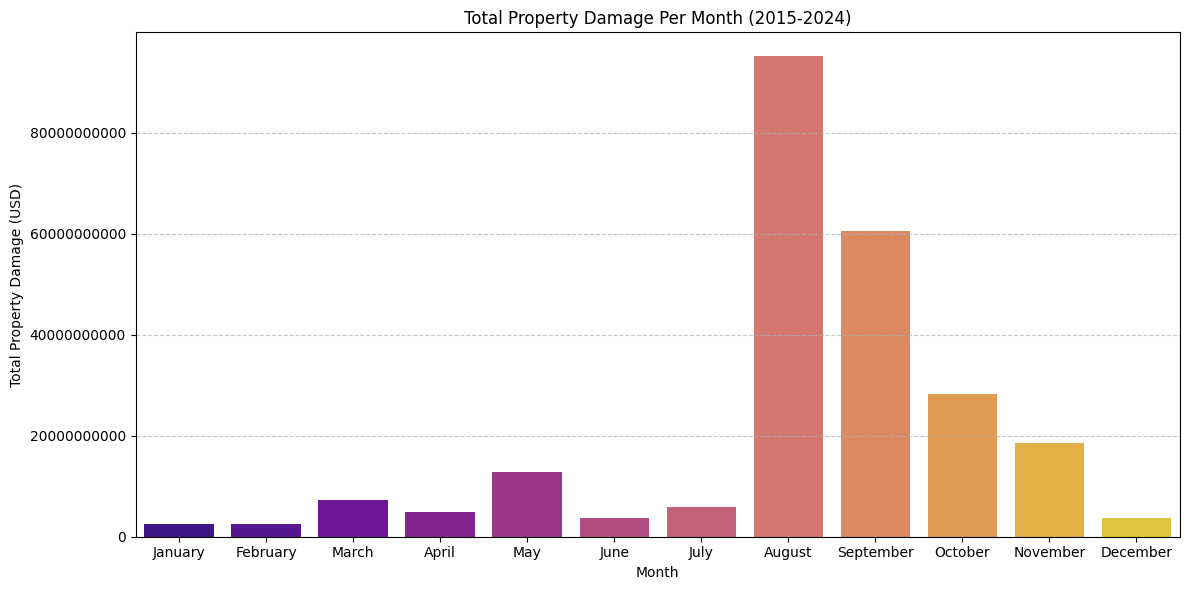

In [30]:
# Calculate total property damage per month
damage_per_month = storm_data.groupby('MONTH_NAME')['DAMAGE_PROPERTY_NUM'].sum().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December']
)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=damage_per_month.index, y=damage_per_month.values, palette='plasma', hue=damage_per_month.index, legend=False)
plt.title('Total Property Damage Per Month (2015-2024)')
plt.xlabel('Month')
plt.ylabel('Total Property Damage (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.tight_layout()
plt.show()

#### Total Direct Injuries

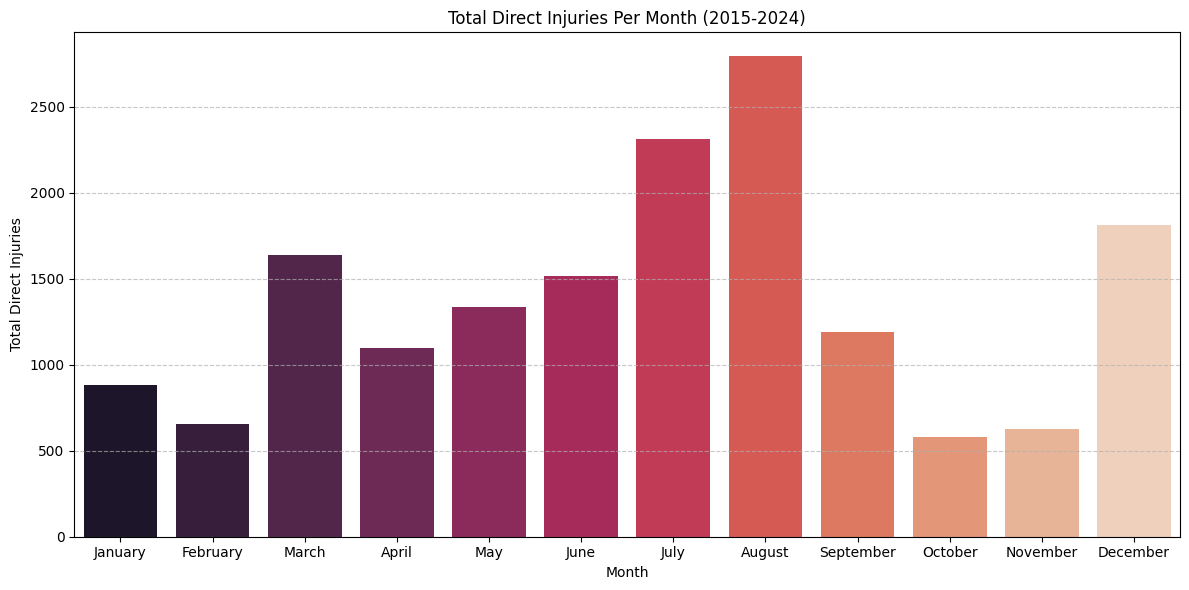

In [31]:
# Calculate total direct injuries per month
injuries_per_month = storm_data.groupby('MONTH_NAME')['INJURIES_DIRECT'].sum().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December']
)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=injuries_per_month.index, y=injuries_per_month.values, palette='rocket', hue=injuries_per_month.index, legend=False)
plt.title('Total Direct Injuries Per Month (2015-2024)')
plt.xlabel('Month')
plt.ylabel('Total Direct Injuries')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Total Direct Deaths

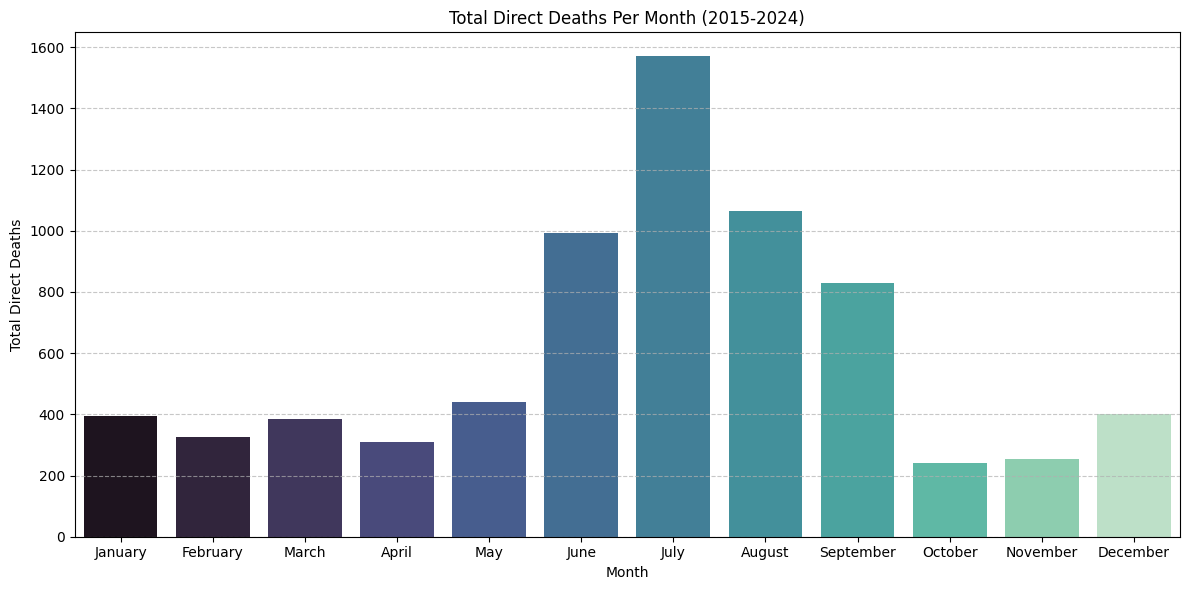

In [32]:
# Calculate total direct deaths per month
deaths_per_month = storm_data.groupby('MONTH_NAME')['DEATHS_DIRECT'].sum().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December']
)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=deaths_per_month.index, y=deaths_per_month.values, palette='mako', hue=deaths_per_month.index, legend=False)
plt.title('Total Direct Deaths Per Month (2015-2024)')
plt.xlabel('Month')
plt.ylabel('Total Direct Deaths')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Seasonal Trends

In [33]:
# Define seasons based on months
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

storm_data['SEASON'] = storm_data['MONTH'].apply(get_season)

# Reorder seasons for plotting
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
storm_data['SEASON'] = pd.Categorical(storm_data['SEASON'], categories=season_order, ordered=True)

print('Updated DataFrame head with SEASON column:')
display(storm_data[['BEGIN_DATE_TIME', 'MONTH', 'MONTH_NAME', 'SEASON']].head())
print('\nSeason distribution:')
display(storm_data['SEASON'].value_counts())

Updated DataFrame head with SEASON column:


,BEGIN_DATE_TIME,MONTH,MONTH_NAME,SEASON
0,2015-09-18 15:44:00,9,September,Fall
1,2015-01-27 12:00:00,1,January,Winter
2,2015-01-24 07:00:00,1,January,Winter
3,2015-01-27 06:00:00,1,January,Winter
4,2015-02-14 08:00:00,2,February,Winter



Season distribution:


,count
SEASON,
Summer,240231
Spring,172494
Winter,143005
Fall,83737


#### Number of Storm Events

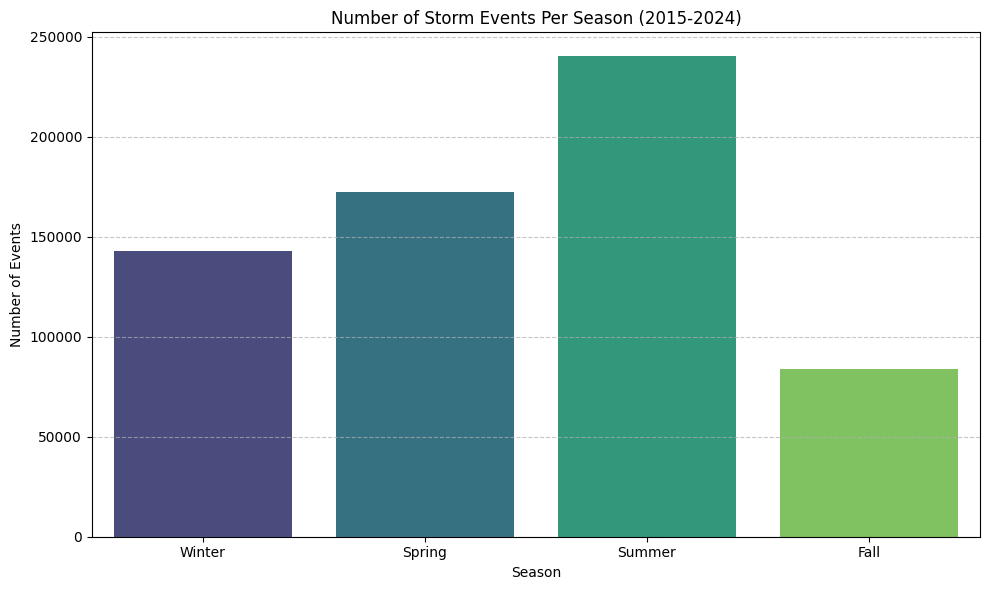

In [34]:
# Calculate number of events per season
events_per_season = storm_data['SEASON'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=events_per_season.index, y=events_per_season.values, palette='viridis', hue=events_per_season.index, legend=False)
plt.title('Number of Storm Events Per Season (2015-2024)')
plt.xlabel('Season')
plt.ylabel('Number of Events')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Total Property Damage

/tmp/ipykernel_1030/1910083277.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  damage_per_season = storm_data.groupby('SEASON')['DAMAGE_PROPERTY_NUM'].sum()


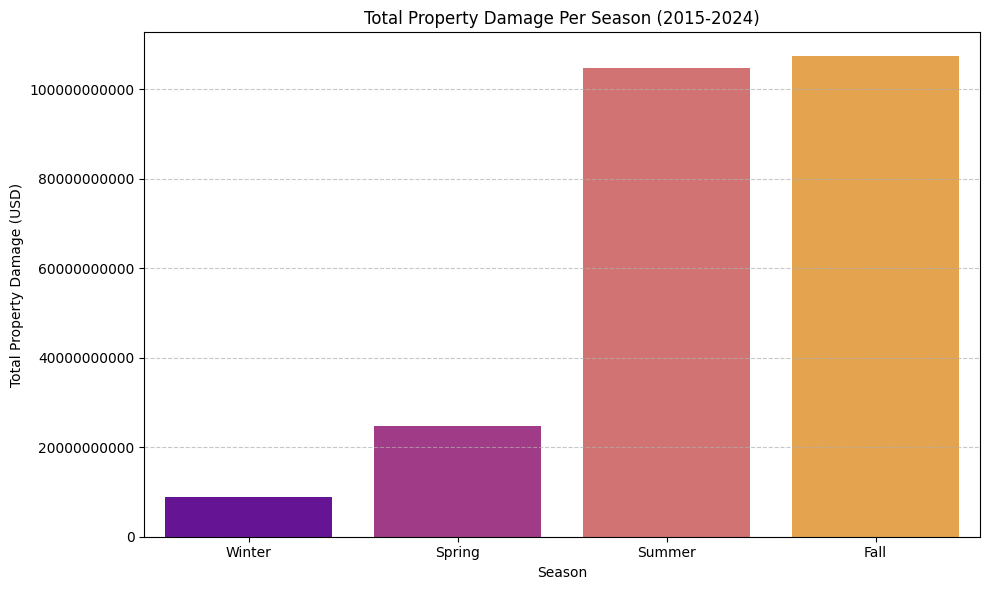

In [35]:
# Calculate total property damage per season
damage_per_season = storm_data.groupby('SEASON')['DAMAGE_PROPERTY_NUM'].sum()

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=damage_per_season.index, y=damage_per_season.values, palette='plasma', hue=damage_per_season.index, legend=False)
plt.title('Total Property Damage Per Season (2015-2024)')
plt.xlabel('Season')
plt.ylabel('Total Property Damage (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.tight_layout()
plt.show()

#### Total Direct Injuries

/tmp/ipykernel_1030/650818709.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  injuries_per_season = storm_data.groupby('SEASON')['INJURIES_DIRECT'].sum()


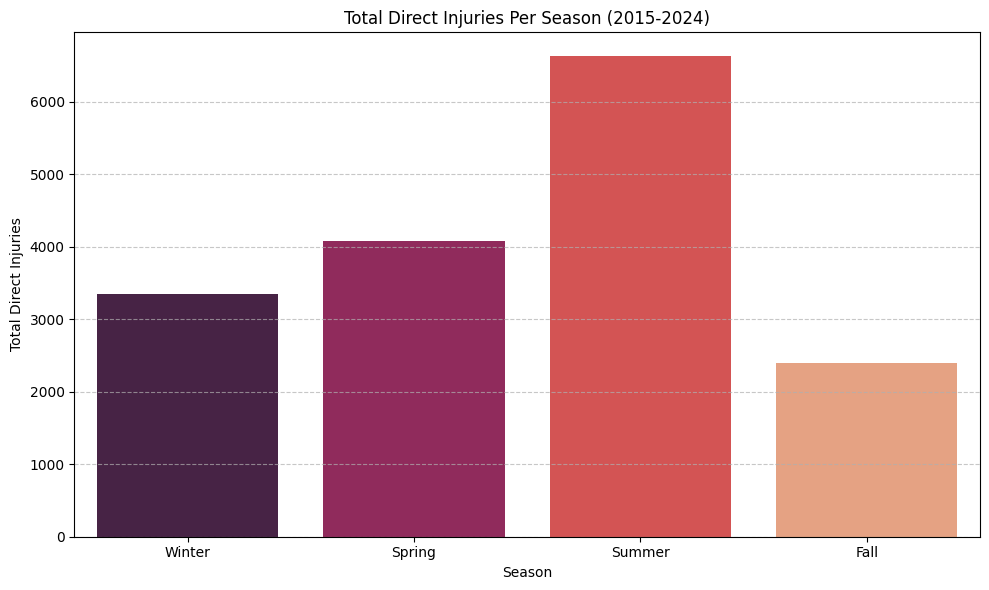

In [36]:
# Calculate total direct injuries per season
injuries_per_season = storm_data.groupby('SEASON')['INJURIES_DIRECT'].sum()

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=injuries_per_season.index, y=injuries_per_season.values, palette='rocket', hue=injuries_per_season.index, legend=False)
plt.title('Total Direct Injuries Per Season (2015-2024)')
plt.xlabel('Season')
plt.ylabel('Total Direct Injuries')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Total Direct Deaths

/tmp/ipykernel_1030/3032606413.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deaths_per_season = storm_data.groupby('SEASON')['DEATHS_DIRECT'].sum()


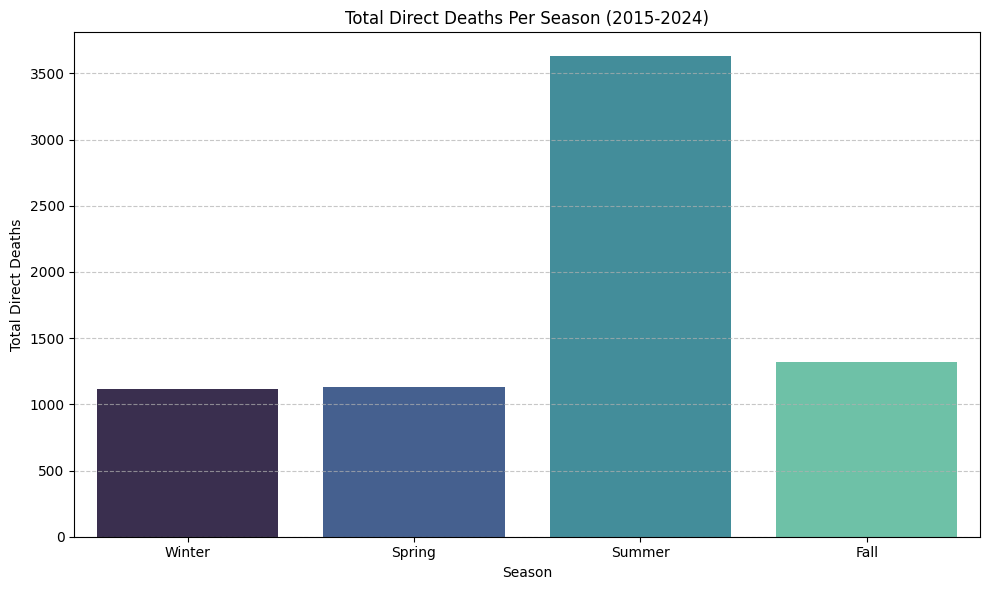

In [37]:
# Calculate total direct deaths per season
deaths_per_season = storm_data.groupby('SEASON')['DEATHS_DIRECT'].sum()

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=deaths_per_season.index, y=deaths_per_season.values, palette='mako', hue=deaths_per_season.index, legend=False)
plt.title('Total Direct Deaths Per Season (2015-2024)')
plt.xlabel('Season')
plt.ylabel('Total Direct Deaths')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Property Damage Prediction

Can `DAMAGE_PROPERTY_NUM` be predicted from a storm event's type, location, season, injuries, and deaths?

### Preparing the Data

Selecting a small feature set and dropping rows with no reported damage value. `EVENT_TYPE` and `STATE` each have 50+ categories, one-hot encoding both would create 100+ sparse columns, so frequency encoding (replacing each category with how often it occurs) is used instead to keep the feature matrix small and dense. `SEASON` has only 4 levels, so one-hot encoding is used there.

In [38]:
df_model = storm_data.copy()

# Select relevant features for the prediction model
selected_features = [
    'EVENT_TYPE',
    'STATE',
    'SEASON',
    'INJURIES_DIRECT',
    'DEATHS_DIRECT',
    'DAMAGE_PROPERTY_NUM'
]

df_model = df_model[selected_features]

# Drop rows where the target variable 'DAMAGE_PROPERTY_NUM' is NaN
df_model.dropna(subset=['DAMAGE_PROPERTY_NUM'], inplace=True)

print("DataFrame head after selecting features and dropping NaN in DAMAGE_PROPERTY_NUM:")
display(df_model.head())

print("\nInfo of the new df_model:")
df_model.info()

DataFrame head after selecting features and dropping NaN in DAMAGE_PROPERTY_NUM:


,EVENT_TYPE,STATE,SEASON,INJURIES_DIRECT,DEATHS_DIRECT,DAMAGE_PROPERTY_NUM
0,Tornado,ILLINOIS,Fall,0,0,70000.0
1,Winter Storm,NEW HAMPSHIRE,Winter,0,0,0.0
2,Heavy Snow,NEW HAMPSHIRE,Winter,0,0,0.0
3,Blizzard,NEW HAMPSHIRE,Winter,0,0,0.0
4,Heavy Snow,NEW HAMPSHIRE,Winter,0,0,0.0



Info of the new df_model:
<class 'pandas.core.frame.DataFrame'>
Index: 506905 entries, 0 to 639466
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   EVENT_TYPE           506905 non-null  object  
 1   STATE                506905 non-null  object  
 2   SEASON               506905 non-null  category
 3   INJURIES_DIRECT      506905 non-null  int64   
 4   DEATHS_DIRECT        506905 non-null  int64   
 5   DAMAGE_PROPERTY_NUM  506905 non-null  float64 
dtypes: category(1), float64(1), int64(2), object(2)
memory usage: 23.7+ MB


In [39]:
# Frequency-encode the high-cardinality categoricals (EVENT_TYPE, STATE)
# instead of one-hot, to keep the feature matrix small and dense.
for col in ['EVENT_TYPE', 'STATE']:
    freq_map = df_model[col].value_counts(normalize=True)
    df_model[col + '_FREQ'] = df_model[col].map(freq_map)

df_model.drop(columns=['EVENT_TYPE', 'STATE'], inplace=True)

# SEASON has only 4 levels, one-hot is fine here
df_model = pd.get_dummies(df_model, columns=['SEASON'], drop_first=True)

print(f"Final feature matrix shape: {df_model.shape}")
display(df_model.head())

Final feature matrix shape: (506905, 8)


,INJURIES_DIRECT,DEATHS_DIRECT,DAMAGE_PROPERTY_NUM,EVENT_TYPE_FREQ,STATE_FREQ,SEASON_Spring,SEASON_Summer,SEASON_Fall
0,0,0,70000.0,0.024263,0.037311,False,False,True
1,0,0,0.0,0.043190,0.003360,False,False,False
2,0,0,0.0,0.034649,0.003360,False,False,False
3,0,0,0.0,0.006865,0.003360,False,False,False
4,0,0,0.0,0.034649,0.003360,False,False,False


### Choosing a model

`DAMAGE_PROPERTY_NUM` is heavily right-skewed (lots of low/zero-damage events, a few huge ones), so the target is log-transformed (`log1p`) before fitting — this keeps the handful of extreme events from dominating the fit. Both models below are trained on the log-transformed target.

Comparing two models with 5-fold cross-validation:
- **Linear Regression** — simple baseline, tells us how much signal is roughly linear
- **Random Forest** — handles non-linear relationships and interactions between features

Cross-validation scores are kept in log space, since that's the scale being modeled. Converting to dollars fold-by-fold with `expm1()` would let one bad prediction on an unfamiliar category blow up the score. Converting back to dollars only happens once, at the very end, on the final chosen model with predictions clipped to a sane range first.

In [40]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df_model.drop('DAMAGE_PROPERTY_NUM', axis=1)
y = df_model['DAMAGE_PROPERTY_NUM']

print(f"Features: {list(X.columns)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Hold out a final test set; cross-validation below uses only the training portion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log_y_train = np.log1p(y_train)

print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")

Features: ['INJURIES_DIRECT', 'DEATHS_DIRECT', 'EVENT_TYPE_FREQ', 'STATE_FREQ', 'SEASON_Spring', 'SEASON_Summer', 'SEASON_Fall']
X shape: (506905, 7), y shape: (506905,)
Training shape: (405524, 7), Test shape: (101381, 7)


In [41]:
# 5-fold cross-validation, scored on the log-transformed target (in log-dollar units,
# not raw dollars — lower is better either way).

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)

lr_scores = -cross_val_score(lr, X_train, log_y_train, cv=5, scoring='neg_mean_absolute_error')
rf_scores = -cross_val_score(rf, X_train, log_y_train, cv=5, scoring='neg_mean_absolute_error')

cv_summary = pd.DataFrame({
    'Linear Regression': [lr_scores.mean(), lr_scores.std()],
    'Random Forest':     [rf_scores.mean(), rf_scores.std()],
}, index=['Mean CV MAE (log scale)', 'Std CV MAE (log scale)']).T

print("5-fold cross-validation results (log-scale MAE, lower is better):")
display(cv_summary)

5-fold cross-validation results (log-scale MAE, lower is better):


,Mean CV MAE (log scale),Std CV MAE (log scale)
Linear Regression,2.940337,0.006508
Random Forest,1.878440,0.006628


### Final model

Whichever row has the lower **Mean CV MAE** above wins. Set `FINAL_MODEL` below to match: `'linear'` or `'random_forest'`.

If Linear Regression is close to Random Forest, that means most of the predictive signal is roughly linear once the target is log-transformed, and the extra complexity of a Random Forest isn't buying much.

In [42]:
# Set this based on the cv_summary results above
FINAL_MODEL = 'random_forest'  # 'linear' or 'random_forest'

if FINAL_MODEL == 'linear':
    final_model = LinearRegression()
else:
    final_model = RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)

final_model.fit(X_train, log_y_train)

# Predict in log space, then convert back to dollars.
# Clip to the range actually seen in training first — without this, a single
# unusual feature combination can produce a slightly-too-large log prediction,
# and expm1() turns that small log-scale miss into an absurd dollar-scale error.
log_pred = np.clip(final_model.predict(X_test), log_y_train.min(), log_y_train.max())
y_pred = np.expm1(log_pred)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Final model: {FINAL_MODEL}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R-squared (R2): {r2:.4f}")

Final model: random_forest
Mean Absolute Error (MAE): 615,613.02
Root Mean Squared Error (RMSE): 51,410,764.35
R-squared (R2): 0.0672


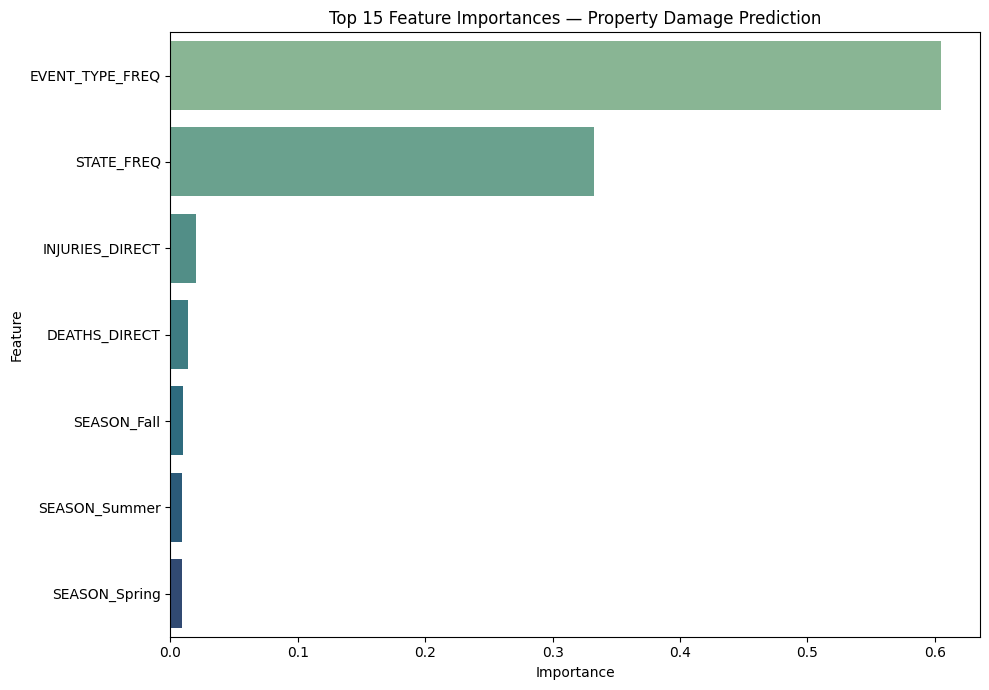

In [43]:
# Feature importance (Random Forest) or coefficients (Linear Regression)
if FINAL_MODEL == 'random_forest':
    importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
    top = importances.sort_values(ascending=False).head(15)
    xlabel = 'Importance'
    title = 'Top 15 Feature Importances — Property Damage Prediction'
else:
    coefs = pd.Series(final_model.coef_, index=X_train.columns)
    top = coefs.sort_values(key=abs, ascending=False).head(15)
    xlabel = 'Coefficient (log-damage scale)'
    title = 'Top 15 Linear Regression Coefficients — Property Damage Prediction'

plt.figure(figsize=(10, 7))
sns.barplot(y=top.index, x=top.values, palette='crest', hue=top.index, legend=False)
plt.title(title)
plt.xlabel(xlabel)
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Model Evaluation

Random Forest outperformed Linear Regression in cross-validation (mean CV MAE of 1.88 vs. 2.94, log-dollar scale), indicating the relationship between event characteristics and damage is meaningfully non-linear.

On the held-out test set, the final Random Forest model achieved:
- **MAE:** $615,613
- **RMSE:** $51,410,764
- **R²:** 0.067

The large gap between MAE and RMSE (RMSE is roughly 80x larger) reflects how skewed `DAMAGE_PROPERTY_NUM` is: RMSE penalizes large errors quadratically, so a small number of catastrophic-damage events the model badly misestimates dominate that metric, while MAE reflects the much smaller typical error on the bulk of lower-damage events.

R² of 0.067 means the model explains only a small share of the variance in property damage. That's expected given the feature set: `EVENT_TYPE`, `STATE`, `SEASON`, injuries, and deaths capture some signal, but the biggest drivers of damage, storm intensity/magnitude, wind speed, local building density and exposure aren't available in this dataset. The model is better understood as a baseline that captures categorical risk patterns (which event types and states tend toward higher damage) than as a precise damage estimator.

**Feature importance:** `EVENT_TYPE_FREQ` and `STATE_FREQ` are by far the two strongest predictors, together accounting for the large majority of the model's importance, how common the event type and state are in the data carries far more signal than injuries, deaths, or season. This makes sense: certain event types (e.g. tornadoes, hurricanes) are inherently higher-damage regardless of where or when they occur, and some states see disproportionately high-damage events. Injuries, deaths, and season contribute comparatively little on their own.

## 8. Key Findings

- **Frequency and impact are disconnected.** Thunderstorm Wind and Hail are by far the most common event types, but Tornadoes, a much smaller share of events account for disproportionately high damage, injuries, and deaths.
- **Damage and event counts show clear seasonal and geographic concentration**, visible in both the state-level breakdowns and the geospatial hotspot maps.
- **Event type and state matter far more than the human-toll or seasonal features for predicting damage.** A Random Forest using these features clearly outperformed a linear baseline (CV MAE 1.88 vs. 2.94, log scale), but the low test R² (0.067) shows there's a ceiling on how well damage can be predicted without storm severity data.

## 9. Limitations & Future Work

**Limitations:**
- No storm severity fields (wind speed, magnitude, Fujita/EF scale) — the single biggest gap limiting predictive power.
- Frequency encoding captures how common a category is, not which specific category — a more informative encoding could recover additional signal.
- Neither model's hyperparameters were tuned; a quick grid search over `max_depth` and `n_estimators` would likely improve the Random Forest further.
- 2024 damage values are largely unpopulated in the NOAA release used here, so 2024 is excluded from the yearly damage plot; monthly, seasonal, and state damage totals and the model use whatever 2024 values exist.
- Frequency encoding is computed on the full dataset before the train/test split, a small source of leakage; fitting the encoding on the training set only would be cleaner.

**Future work:**
- Incorporate storm severity fields (e.g. wind speed, magnitude) if available in the raw NCEI data — likely the single biggest lever on model performance.
- Tune model hyperparameters via grid or random search.
- Consider a two-stage model: classify "damage vs. no damage" first, then predict magnitude only for damage-positive events — a common approach for zero-inflated targets like this one.